In [8]:
import tensorflow as tf 
import tensorflow_hub as hub
import numpy as np 
import cv2 
import matplotlib.pyplot as plt 
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip

### Importing the video file 

In [12]:
import os
import glob

# 1. Your Base Path
base_path = r'/Users/Olu/Documents/Tensorflow_particesWork/TF_wroks/Synthetic Media for Real Estate:E-commerce'

def auto_find_and_load(path, target_size=(512, 512)):
    # This search pattern looks for images in ALL subfolders (**)
    search_pattern = os.path.join(path, '**', '*.[jJ][pP]*[gG]')
    image_paths = glob.glob(search_pattern, recursive=True)
    
    # Also look for .png files just in case
    image_paths += glob.glob(os.path.join(path, '**', '*.[pP][nN][gG]'), recursive=True)
    
    print(f"Found {len(image_paths)} images total across all folders.")
    
    dataset = []
    for img_p in sorted(image_paths):
        img = cv2.imread(img_p)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, target_size)
            img = img / 255.0  # Normalize
            dataset.append(img)
            
    return np.array(dataset)

# Run the loader
image_batch = auto_find_and_load(base_path)

if len(image_batch) > 0:
    print(f"Success! Batch Shape: {image_batch.shape}")
else:
    print("Still 0 images. Check if you have a folder like 'test_images' inside that path.")

Found 279 images total across all folders.
Success! Batch Shape: (279, 512, 512, 3)


### Double checking for matching picture 

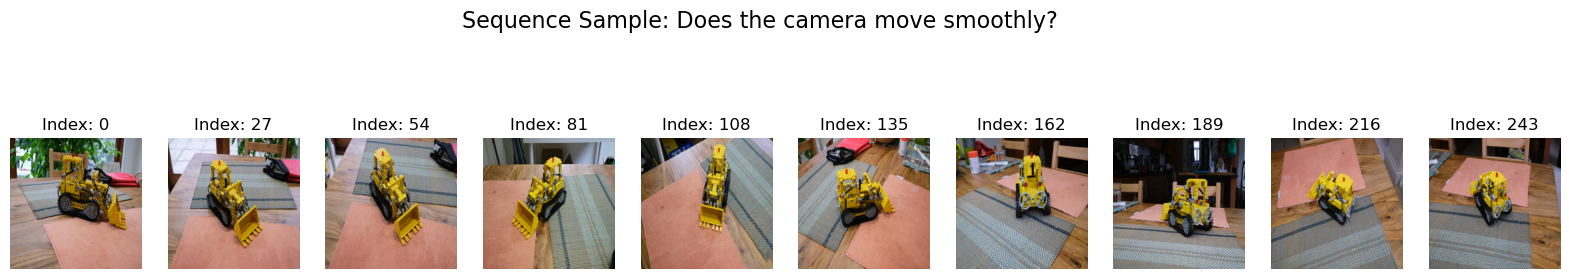

In [13]:
def check_sequence(batch, num_to_show=10):
    # Calculate how many photos to skip to see the whole range
    step = len(batch) // num_to_show
    
    plt.figure(figsize=(20, 4))
    for i in range(num_to_show):
        idx = i * step
        plt.subplot(1, num_to_show, i + 1)
        plt.imshow(batch[idx])
        plt.title(f"Index: {idx}")
        plt.axis('off')
    plt.suptitle("Sequence Sample: Does the camera move smoothly?", fontsize=16)
    plt.show()

check_sequence(image_batch)

In [14]:
# 1. Select two overlapping images
# (use 0 and 10 to ensure there is enough 'movement' to measure)
img1 = (image_batch[0] * 255).astype('uint8')
img2 = (image_batch[10] * 255).astype('uint8')

# 2. Extract Features (Landmarks)
orb = cv2.ORB_create(nfeatures=1500)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# 3. Match the landmarks
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# 4. Convert matches to coordinates (X, Y)
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

# 5. THE SFM MATH: Find the Essential Matrix
# This calculates the geometry between the two camera positions
#  a standard focal length (960) for a typical camera
E, mask = cv2.findEssentialMat(pts1, pts2, focal=960.0, pp=(256, 256), method=cv2.RANSAC, prob=0.999, threshold=1.0)

# 6. Recover the Pose (Rotation and Translation)
_, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2)

print("--- Camera Motion Detected ---")
print("Rotation Matrix:\n", R)
print("\nTranslation Vector (Movement Direction):\n", t)

--- Camera Motion Detected ---
Rotation Matrix:
 [[ 0.98922449 -0.1441763  -0.02545787]
 [ 0.14343552  0.98923863 -0.02886487]
 [ 0.02934554  0.02490227  0.99925908]]

Translation Vector (Movement Direction):
 [[-0.10583029]
 [ 0.02070706]
 [-0.99416858]]


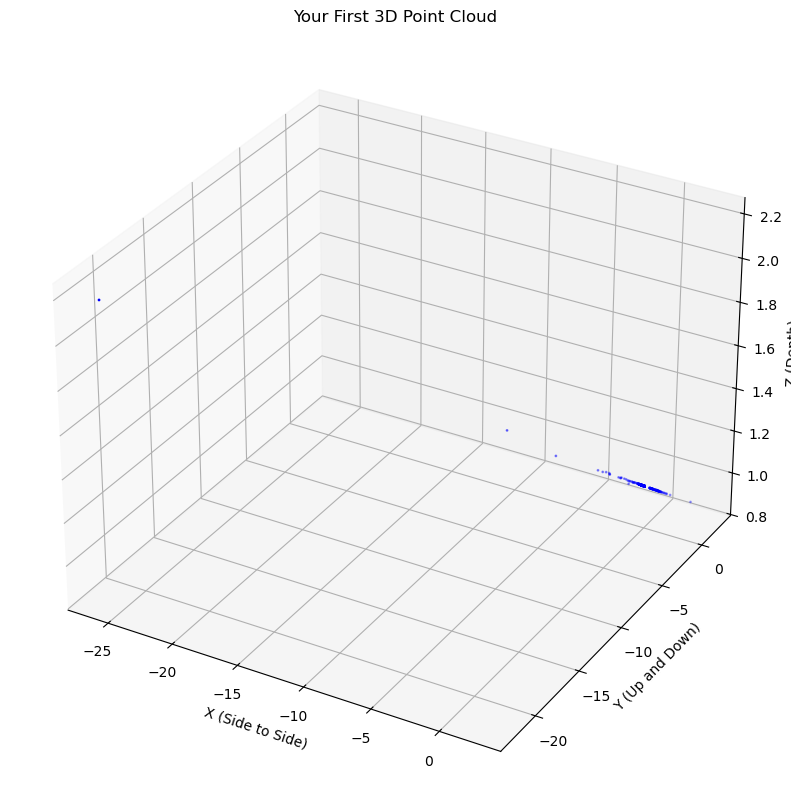

In [15]:
# 1. Triangulate the points to get 3D coordinates (X, Y, Z)
# This uses the Camera Pose (R, t) we just calculated
proj_matrix1 = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0]])
proj_matrix2 = np.hstack((R, t))

# Triangulate points
pts4D = cv2.triangulatePoints(proj_matrix1, proj_matrix2, pts1.T, pts2.T)
pts3D = pts4D[:3, :] / pts4D[3, :] # Convert from homogeneous to 3D

# 2. Visualize in a 3D Scatter Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Filter out points that are too far away (noise)
mask = (pts3D[2, :] > 0) & (pts3D[2, :] < 10) 
ax.scatter(pts3D[0, mask], pts3D[1, mask], pts3D[2, mask], c='blue', s=1)

ax.set_xlabel('X (Side to Side)')
ax.set_ylabel('Y (Up and Down)')
ax.set_zlabel('Z (Depth)')
plt.title("Your First 3D Point Cloud")
plt.show()

### Creating a professional folder structure for 3D reconstruction

In [16]:
# Creating a professional folder structure for 3D reconstruction
project_name = "Real_Estate_3D_Project"
os.makedirs(f"{project_name}/input", exist_ok=True)

# Save your processed images into the 'input' folder
# (We use the original images so the AI has the most detail)
for i, img in enumerate(image_batch):
    # Convert back to 0-255 for saving
    save_img = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_RGB2BGR)
    cv2.imwrite(f"{project_name}/input/frame_{i:03d}.jpg", save_img)

print(f"Project ready in folder: {project_name}/input")
print("You now have a clean dataset ready for COLMAP or Gaussian Splatting!")

Project ready in folder: Real_Estate_3D_Project/input
You now have a clean dataset ready for COLMAP or Gaussian Splatting!


In [28]:
from matplotlib.animation import PillowWriter

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# REMOVED THE MASK: Let's see everything first to find where the tractor is
ax.scatter(pts3D[0, :], pts3D[1, :], pts3D[2, :], 
           c=pts3D[2, :], cmap='viridis', s=2)

ax.set_title("LEGO Tractor: Full Point Cloud")

# Use a larger step (10) to make the file save very quickly so you can check it
writer = PillowWriter(fps=20)
with writer.saving(fig, "tractor_3D_v2.gif", dpi=100):
    for angle in range(0, 360, 10): 
        ax.view_init(elev=20, azim=angle)
        writer.grab_frame()

print("New GIF 'tractor_3D_v2.gif' created. Check if the dots appear now!")

<IPython.core.display.Javascript object>

New GIF 'tractor_3D_v2.gif' created. Check if the dots appear now!


In [19]:
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from IPython.display import Video

# Get the list of images we just saved to the folder
image_files = [f"Real_Estate_3D_Project/input/frame_{i:03d}.jpg" for i in range(len(image_batch))]

# Create a 24fps video
clip = ImageSequenceClip(image_files, fps=24)
clip.write_videofile("walkthrough_check.mp4", codec="libx264")

# Display it in the notebook
Video("walkthrough_check.mp4", width=600)

MoviePy - Building video walkthrough_check.mp4.
MoviePy - Writing video walkthrough_check.mp4



MoviePy - Done !
MoviePy - video ready walkthrough_check.mp4


In [20]:
# Create a slower playback (10 frames per second instead of 24)
slow_clip = ImageSequenceClip(image_files, fps=10) 
slow_clip.write_videofile("walkthrough_slow.mp4", codec="libx264")

# Display the slow version
Video("walkthrough_slow.mp4", width=600)


MoviePy - Building video walkthrough_slow.mp4.
MoviePy - Writing video walkthrough_slow.mp4



MoviePy - Done !
MoviePy - video ready walkthrough_slow.mp4


In [22]:
%matplotlib notebook
# %matplotlib widget